# CrisisLexT26

Domain Adaptation with Adversarial Training and Graph Embeddings

---

## A. Original description

There are three files per crisis, for each of the following disasters:
- 2012_Colorado_wildfires
- 2012_Costa_Rica_earthquake
- 2012_Guatemala_earthquake
- 2012_Italy_earthquakes
- 2012_Philipinnes_floods
- 2012_Typhoon_Pablo
- 2012_Venezuela_refinery
- 2013_Alberta_floods
- 2013_Australia_bushfire
- 2013_Bohol_earthquake
- 2013_Boston_bombings
- 2013_Brazil_nightclub_fire
- 2013_Colorado_floods
- 2013_Glasgow_helicopter_crash
- 2013_LA_airport_shootings
- 2013_Lac_Megantic_train_crash
- 2013_Manila_floods
- 2013_NY_train_crash
- 2013_Queensland_floods
- 2013_Russia_meteor
- 2013_Sardinia_floods
- 2013_Savar_building_collapse
- 2013_Singapore_haze
- 2013_Spain_train_crash
- 2013_Typhoon_Yolanda
- 2013_West_Texas_explosion


Each directory contains tweets posted during event, organized in two comma-separated values (.csv) files containing tweet-ids for all the tweets filtered for this event, plus the text of the tweets and labels only for the labeled ones. The directory also contains a file with details about the event.

#### Event description file `*-event_description.json`

**Contents:** This file contains location and temporal details about the event, along with a brief categorization, collection size, and the list of keywords used for filtering.

**Data Format:** JSON (check file)

**Top-level fields:** name, time, location, categorization, keywords, size

#### Labeled tweets file `*-tweets_labeled.csv`

**Contents:** This file contains slightly above 1000 tweets labeled by crowdsourcing workers according to *informativeness* (as informative, or not informative), *information type*, and *source*. Each tweet is accompanied by three labels, each being the result of the majority voting among at least 3 crowdsourcing workers.

**Data Format:** One tweet per line with the following comma-separated fields:
*Tweet ID, Tweet Text, Information Source, Information Type, Informativeness*

**Labels:**
The file contains labels provided by crowdsource workers, indicating if the tweet is:

 - *Informativeness:* Related and informative, Related - but not informative, Not related, Not applicable
 - *Information source:* Eyewitness, Government, NGOs, Business, Media, Outsiders, Not applicable
 - *Information type:* Affected individuals, Infrastructure and utilities, Donations and volunteering, Caution and advice, Sympathy and support, Other Useful Information, Not applicable

A description of the labeling process can be found in the reference below.

#### Tweet ids file `*-tweetids_entire_period`

**Contents:** This file contains a list of tweet-ids for all the tweets filtered for this event.

**Data Format:** One tweet per line with the following comma-separated fields:
  *Timestamp, Tweet-ID, Included*

**"Included" field:**
The "Included" file indicates if the tweet was included in the period we analyzed (Y) or not (N). The inclusion/exclusion rule is based on frequency over time as detailed in the reference below.

### Reference

[Olteanu et al. 2015] A. Olteanu, S. Vieweg, C. Castillo. 2015. What to Expect When the Unexpected Happens: Social Media Communications Across Crises. In Proceedings of the ACM 2015 Conference on Computer Supported Cooperative Work and Social Computing (CSCW '15). ACM, Vancouver, BC, Canada.

### Questions/inquiries

For inquiries please contact [Alexandra Olteanu](mailto:alexandra.olteanu@epfl.ch), or Sarah Vieweg, or Carlos Castillo.
 

## B. Overview

In [8]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisLexT26' / 'CrisisLexT26'

Loading the `2012_Colorado_wildfires.csv` file

In [9]:
filepath = dataset_path / '2012_Colorado_wildfires' / '2012_Colorado_wildfires-tweets_labeled.csv'

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df = pd.read_csv(filepath)
df.columns = df.columns.str.strip()

In [10]:
df.head()

,Tweet ID,Tweet Text,Information Source,Information Type,Informativeness
0,211040709124440064,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,Not labeled,Not labeled,Not related
1,211111710294163457,RT @Jack4Ward: Get in on the fun every Thursda...,Not labeled,Not labeled,Not related
2,211157222699433985,Welcome to our newest STUDENTathlete- Reagan B...,Not labeled,Not labeled,Not related
3,211162553659830272,Denver Post: #Colorado governor signs bill cre...,Not labeled,Not labeled,Not related
4,211216962162933761,Pretty sure I'm going to live in Manitou Sprin...,Not labeled,Not labeled,Not related


In [11]:
csv_array = df.values

print(f'Loaded {len(df)} rows from: {filepath}')
print(csv_array[:5])

Loaded 1200 rows from: /Users/nhut/Library/CloudStorage/GoogleDrive-nduo221@aucklanduni.ac.nz/Shared drives/Nhut - Disaster on Social Media - COMPSCI 792 Research Project/Datasets/CrisisLexT26/CrisisLexT26/2012_Colorado_wildfires/2012_Colorado_wildfires-tweets_labeled.csv
[[211040709124440064
  '#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #Florida #Colorado #Iowa #Nevada #Virginia #NV #mlb Travel Destinations---&gt;http://t.co/TIHBJKF2'
  'Not labeled' 'Not labeled' 'Not related']
 [211111710294163457
  'RT @Jack4Ward: Get in on the fun every Thursday with the @csindependent #FunBrief http://ow.ly/br9Wi #CoSprings #Colorado'
  'Not labeled' 'Not labeled' 'Not related']
 [211157222699433985
  'Welcome to our newest STUDENTathlete- Reagan Biechler\xa0from Colorado Springs (CO) ’13- Baseball. http://t.co/lzeiYMpq'
  'Not labeled' 'Not labeled' 'Not related']
 [211162553659830272
  'Denver Post: #Colorado governor signs bill creating rules for public access to ballots http://t.co/Hmp1wQ8P

## C. Preprocess

Combine all train, dev, test files from both events to one

In [12]:
df[df["Informativeness"]=='Not applicable'].head()

,Tweet ID,Tweet Text,Information Source,Information Type,Informativeness
7,211281973870727170,#colorado. Told you its #amazing http://t.co/6...,Not labeled,Not labeled,Not applicable
179,213278894600634369,Forlan no Inter: sites na europa dizem que sim...,Not labeled,Not labeled,Not applicable
374,216741229650649088,RT @jeffestes: #weberfire http://t.co/2pZqhWAS...,Not labeled,Not labeled,Not applicable
404,217018900959858688,Ouvir a torcida do meu #Inter cantando na Ilha...,Not labeled,Not labeled,Not applicable
787,218102289687261184,"Colorado Springs, 2e plus grande ville du Colo...",Not labeled,Not labeled,Not applicable


In [13]:
files = [
    {
        "filename": "2012_Colorado_wildfires/2012_Colorado_wildfires-tweets_labeled.csv",
        "country": "US",
        "event_type": "wildfires",
        "year": 2012,
    },
    {
        "filename": "2012_Costa_Rica_earthquake/2012_Costa_Rica_earthquake-tweets_labeled.csv",
        "country": "Costa Rica",
        "event_type": "earthquake",
        "year": 2012,
    },
    {
        "filename": "2012_Guatemala_earthquake/2012_Guatemala_earthquake-tweets_labeled.csv",
        "country": "Guatemala",
        "event_type": "earthquake",
        "year": 2012,
    },
    {
        "filename": "2012_Italy_earthquakes/2012_Italy_earthquakes-tweets_labeled.csv",
        "country": "Italy",
        "event_type": "earthquake",
        "year": 2012,
    },
    {
        "filename": "2012_Philipinnes_floods/2012_Philipinnes_floods-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "flood",
        "year": 2012,
    },
    {
        "filename": "2012_Typhoon_Pablo/2012_Typhoon_Pablo-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "storm",
        "year": 2012,
    },
    {
        "filename": "2013_Alberta_floods/2013_Alberta_floods-tweets_labeled.csv",
        "country": "Canada",
        "event_type": "flood",
        "year": 2013,
    },
    {
        "filename": "2013_Australia_bushfire/2013_Australia_bushfire-tweets_labeled.csv",
        "country": "Australia",
        "event_type": "wildfires",
        "year": 2013,
    },
    {
        "filename": "2013_Bohol_earthquake/2013_Bohol_earthquake-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "earthquake",
        "year": 2013,
    },
    {
        "filename": "2013_Colorado_floods/2013_Colorado_floods-tweets_labeled.csv",
        "country": "US",
        "event_type": "flood",
        "year": 2013,
    },
    {
        "filename": "2013_Manila_floods/2013_Manila_floods-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "flood",
        "year": 2013,
    },
    {
        "filename": "2013_Queensland_floods/2013_Queensland_floods-tweets_labeled.csv",
        "country": "Australia",
        "event_type": "flood",
        "year": 2013,
    },
    {
        "filename": "2013_Russia_meteor/2013_Russia_meteor-tweets_labeled.csv",
        "country": "US",
        "event_type": "incident",
        "year": 2013,
    },
    {
        "filename": "2013_Sardinia_floods/2013_Sardinia_floods-tweets_labeled.csv",
        "country": "US",
        "event_type": "flood",
        "year": 2013,
    },
    {
        "filename": "2013_Singapore_haze/2013_Singapore_haze-tweets_labeled.csv",
        "country": "US",
        "event_type": "haze",
        "year": 2013,
    },
    {
        "filename": "2013_Typhoon_Yolanda/2013_Typhoon_Yolanda-tweets_labeled.csv",
        "country": "US",
        "event_type": "storm",
        "year": 2013,
    },
    # {
    #     "filename": "2012_Venezuela_refinery/2012_Venezuela_refinery-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Glasgow_helicopter_crash/2013_Glasgow_helicopter_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_LA_airport_shootings/2013_LA_airport_shootings-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Lac_Megantic_train_crash/2013_Lac_Megantic_train_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_NY_train_crash/2013_NY_train_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Savar_building_collapse/2013_Savar_building_collapse-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Spain_train_crash/2013_Spain_train_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Boston_bombings/2013_Boston_bombings-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Brazil_nightclub_fire/2013_Brazil_nightclub_fire-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_West_Texas_explosion/2013_West_Texas_explosion-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
]

In [14]:
df_list = []

for file in files:
    filename = file["filename"]
    filepath = dataset_path / filename
    if not filepath.exists():
        print(f"Not found: {filepath}")
        continue

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    # remove `'Not applicable'` in `Informativeness` column
    df = df[df["Informativeness"] != "Not applicable"]

    df.rename(columns={"Tweet ID": "tweet_id"}, inplace=True)
    df.rename(columns={"Tweet Text": "tweet_text"}, inplace=True)
    df["event_type"] = file["event_type"]
    df["country"] = file["country"]
    df["year"] = file["year"]

    # *Informativeness:* Related and informative, Related - but not informative, Not related, Not applicable
    df["relevant"] = df["Informativeness"].apply(lambda x: False if x == "Not related" else True)
    df['dataset'] = 'CrisisLexT26'
    # Store other metadata as JSON text in `meta`.
    df["meta"] = df.apply(
        lambda row: {
            "file_name": filename,
            "Information Source": row["Information Source"],
            "Information Type": row["Information Type"],
            "Informativeness": row["Informativeness"],
        },
        axis=1,
    )
    df.rename(columns={'Informativeness': 'original_label'}, inplace=True)
    df['relevant'] = df['original_label'].apply(
        lambda x: False if x in ['Not applicable', 'Not related'] else True)
    drop_cols = ["Information Source", "Information Type"]
    df.drop(columns=drop_cols, inplace=True)
    df_list.append(df)

# ignore_index=True creates clean, sequential row numbers
merged_df = pd.concat(df_list, ignore_index=True)
merged_df.rename(columns={'text': 'tweet_text'}, inplace=True)
merged_df = merged_df[dataset_settings.dataset_extended_cols]
merged_df.head()

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
0,211040709124440064,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,False,wildfires,CrisisLexT26,Not related,US,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
1,211111710294163457,RT @Jack4Ward: Get in on the fun every Thursda...,False,wildfires,CrisisLexT26,Not related,US,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
2,211157222699433985,Welcome to our newest STUDENTathlete- Reagan B...,False,wildfires,CrisisLexT26,Not related,US,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
3,211162553659830272,Denver Post: #Colorado governor signs bill cre...,False,wildfires,CrisisLexT26,Not related,US,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
4,211216962162933761,Pretty sure I'm going to live in Manitou Sprin...,False,wildfires,CrisisLexT26,Not related,US,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...


In [15]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {merged_df['tweet_text'].duplicated().sum()}")

# # Remove duplicates
merged_df = merged_df.drop_duplicates(subset=['tweet_text'])

merged_df['tweet_text'].value_counts()

Number of duplicate tweets: 1543


tweet_text
#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #Florida #Colorado #Iowa #Nevada #Virginia #NV #mlb Travel Destinations---&gt;http://t.co/TIHBJKF2    1
RT @upictus: 2nd batch of donations (almost 200 pcs. of canned goods) on their way to @usc_upd 's Iskoperation. Thank you so much! #reliefPH       1
RT @DivinemLee: UPDATED FILE: https://t.co/StkbD2ytHA RT #maring #safenow #rescueph                                                                1
*praying* RT @PhilippineStar: PAGASA: #MaringPH may exit Phl area of responsibility tomorrow afternoon. | via @helenmflores                        1
RT @RescuePH: #SafeNow based on our database. RT @annecurtismmith: #RescuePH Please check on Abegail Pascasio sa 104 E.Flores St. Malibay P…       1
                                                                                                                                                  ..
It was predicted that the said Typhoon Pablo is more destructive than Sendong. But we have The 

In [16]:
import csv
# Use QUOTE_ALL to quote all fields, ensuring newlines and special characters are properly handled
merged_df.to_csv('datasets/CrisisLexT26.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifying

In [17]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15682 entries, 0 to 17224
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        15682 non-null  int64 
 1   tweet_text      15682 non-null  object
 2   relevant        15682 non-null  bool  
 3   event_type      15682 non-null  object
 4   dataset         15682 non-null  object
 5   original_label  15682 non-null  object
 6   country         15682 non-null  object
 7   year            15682 non-null  int64 
 8   meta            15682 non-null  object
dtypes: bool(1), int64(2), object(6)
memory usage: 1.1+ MB


In [18]:
merged_df.describe(include='all')

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
count,1.568200e+04,15682,15682,15682,15682,15682,15682,15682.000000,15682
unique,NaN,15682,2,6,1,3,7,NaN,982
top,NaN,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,True,flood,CrisisLexT26,Related and informative,US,NaN,{'file_name': '2012_Costa_Rica_earthquake/2012...
freq,NaN,1,13741,5708,15682,9721,5903,NaN,387
mean,3.142990e+17,NaN,NaN,NaN,NaN,NaN,NaN,2012.617587,NaN
std,6.763157e+16,NaN,NaN,NaN,NaN,NaN,NaN,0.485992,NaN
min,2.034409e+17,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
25%,2.451979e+17,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
50%,3.024947e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
75%,3.814480e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN


<Axes: xlabel='event_type'>

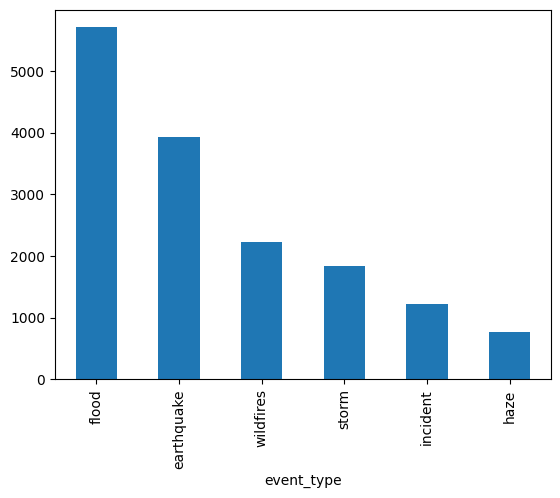

In [19]:
merged_df['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='relevant'>

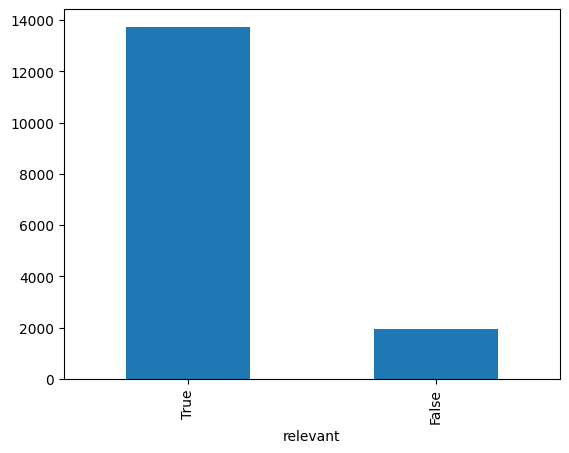

In [20]:
merged_df['relevant'].value_counts().plot(kind='bar')